In [14]:
!git clone https://github.com/zbryantjones/bafad-research-track.git
%cd bafad-research-track/task-a

Cloning into 'bafad-research-track'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 24 (delta 2), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 94.46 KiB | 612.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/bafad-research-track/task-a/bafad-research-track/task-a/bafad-research-track/task-a/bafad-research-track/task-a/bafad-research-track/task-a/bafad-research-track/task-a


# Task A — Exploratory Data Analysis: SMAP Telemetry
BAFAD Accelerated Research Track · Fall 2026

In this notebook I explore a sample of telemetry data from NASA's SMAP satellite.

## 1 · Setup and Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Fixed style matching STAT 270 colour scheme
NAVY  = '#021B3A'
BLUE  = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

# Load the sample dataset
df = pd.read_csv('../data/smap_sample.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Loaded: 500 rows × 27 columns


## 2 · First Look at the Data
**A.** Using `.info()` and `.describe()` to look at the dataset.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  500 non-null    int64  
 1   chan_00    500 non-null    float64
 2   chan_01    500 non-null    float64
 3   chan_02    500 non-null    float64
 4   chan_03    500 non-null    float64
 5   chan_04    500 non-null    float64
 6   chan_05    500 non-null    float64
 7   chan_06    500 non-null    float64
 8   chan_07    500 non-null    float64
 9   chan_08    500 non-null    float64
 10  chan_09    500 non-null    float64
 11  chan_10    500 non-null    float64
 12  chan_11    500 non-null    float64
 13  chan_12    500 non-null    float64
 14  chan_13    500 non-null    float64
 15  chan_14    500 non-null    float64
 16  chan_15    500 non-null    float64
 17  chan_16    500 non-null    float64
 18  chan_17    500 non-null    float64
 19  chan_18    500 non-null    float64
 20  chan_19   

In [17]:
df.describe()

,timestamp,chan_00,chan_01,chan_02,chan_03,chan_04,chan_05,chan_06,chan_07,chan_08,...,chan_16,chan_17,chan_18,chan_19,chan_20,chan_21,chan_22,chan_23,chan_24,anomaly
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,15030.000000,0.014707,0.012190,0.028274,0.019272,0.007134,-0.001609,-0.008584,-0.008491,-0.021960,...,0.039780,0.022125,0.033303,0.023156,0.019360,-0.002823,-0.014540,-0.044000,-0.039156,0.04800
std,8668.909966,0.356819,0.419378,0.437221,0.429701,0.481541,0.463448,0.479479,0.515423,0.533819,...,0.709725,0.732462,0.740952,0.760108,0.792660,0.846386,0.822671,0.865636,0.871447,0.21398
min,60.000000,-0.588100,-3.564040,-0.654510,-0.714480,-3.257240,-0.757030,-0.854760,-0.855550,-0.837470,...,-1.113290,-3.030020,-1.119810,-1.173830,-1.148730,-5.019940,-1.295860,-3.643910,-1.314230,0.00000
25%,7545.000000,-0.328545,-0.368602,-0.365287,-0.394363,-0.426525,-0.455228,-0.478065,-0.508625,-0.559280,...,-0.676052,-0.690743,-0.710070,-0.722268,-0.750848,-0.757110,-0.814723,-0.860980,-0.913103,0.00000
50%,15030.000000,0.037820,0.042780,0.032710,0.038110,0.051000,0.009465,-0.019030,-0.004145,-0.059320,...,0.050270,0.058320,0.082505,0.037025,0.048545,-0.000495,-0.036935,-0.080565,-0.085385,0.00000
75%,22515.000000,0.365538,0.387972,0.418593,0.420992,0.443580,0.458758,0.456877,0.475345,0.516820,...,0.723555,0.732325,0.766210,0.780995,0.756782,0.783923,0.800028,0.833910,0.816553,0.00000
max,30000.000000,0.616390,0.619560,3.338690,2.139420,3.036740,0.764780,0.771170,2.468480,0.827830,...,3.524870,1.118980,1.125470,1.184130,4.287770,3.879340,1.252730,1.264990,1.323300,1.00000


In [18]:
# check for missing values
print('Total missing values:', df.isna().sum().sum())

Total missing values: 0


**Your answer:**

There are 25 telemetry channels (`chan_00` to `chan_24`). The `timestamp` column is just time in seconds and goes up by 60 each row. The `anomaly` column is a label: 1 means that timestep is an anomaly and 0 means it is normal. The check above shows there are no missing values, so every column is full.

## 3 · Anomaly Prevalence
**B.** Count and percentage of timesteps labelled as anomalies.

In [19]:
n_anomaly = int((df['anomaly'] == 1).sum())
pct       = n_anomaly / len(df) * 100
print(f'{n_anomaly} of {len(df)} timesteps are anomalies ({pct:.1f}%).')

24 of 500 timesteps are anomalies (4.8%).


## 4 · Time-Series Visualisation
**C.** `chan_00` over time, with anomaly timesteps in red.

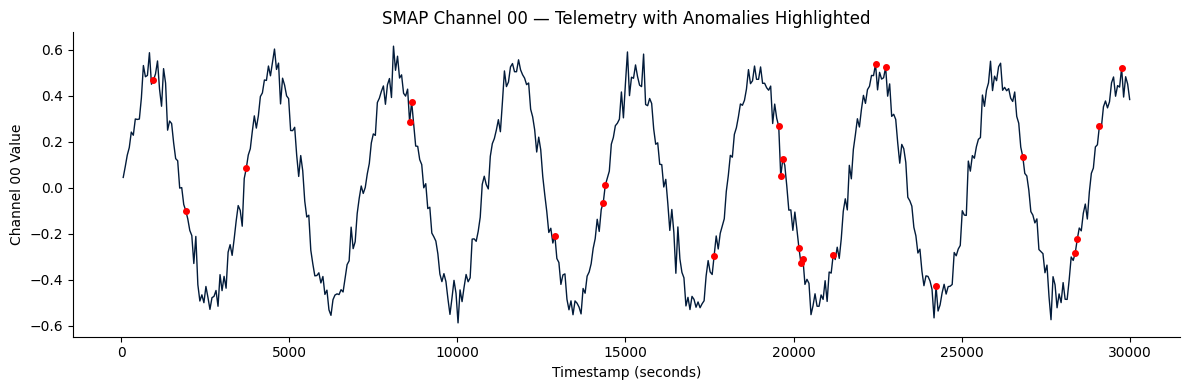

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))

# line for the whole channel
ax.plot(df['timestamp'], df['chan_00'], color=NAVY, linewidth=1)

# red dots on the anomaly timesteps
anom = df[df['anomaly'] == 1]
ax.plot(anom['timestamp'], anom['chan_00'], 'r.', markersize=8)

ax.set_xlabel('Timestamp (seconds)')
ax.set_ylabel('Channel 00 Value')
ax.set_title('SMAP Channel 00 — Telemetry with Anomalies Highlighted')
plt.tight_layout()
plt.show()

## 5 · Multi-Channel Heatmap
**D.** All 25 channels over time. Red lines mark anomaly timesteps.

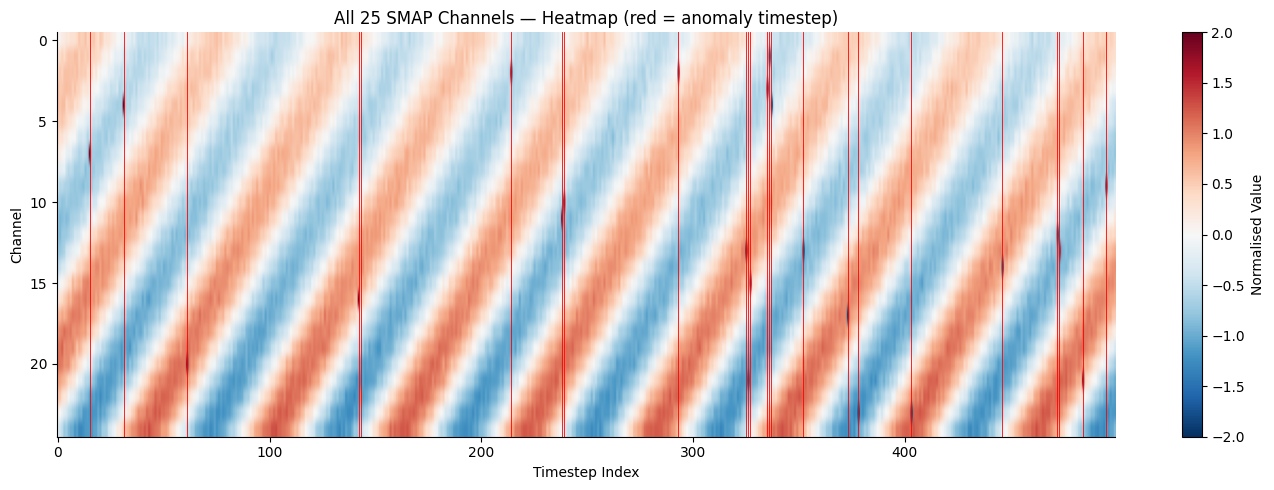

In [21]:
chan_cols = df.filter(like='chan_').columns.tolist()
data_matrix = df[chan_cols].values.T  # shape: (25 channels, 500 timesteps)

fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(data_matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalised Value')

# thin red vertical line at each anomaly timestep
for idx in df.index[df['anomaly'] == 1]:
    ax.axvline(idx, color='red', linewidth=0.6)

ax.set_xlabel('Timestep Index')
ax.set_ylabel('Channel')
ax.set_title('All 25 SMAP Channels — Heatmap (red = anomaly timestep)')
plt.tight_layout()
plt.show()

## 6 · Distribution of Channel Values
**E.** `chan_00` values for normal vs anomaly timesteps.

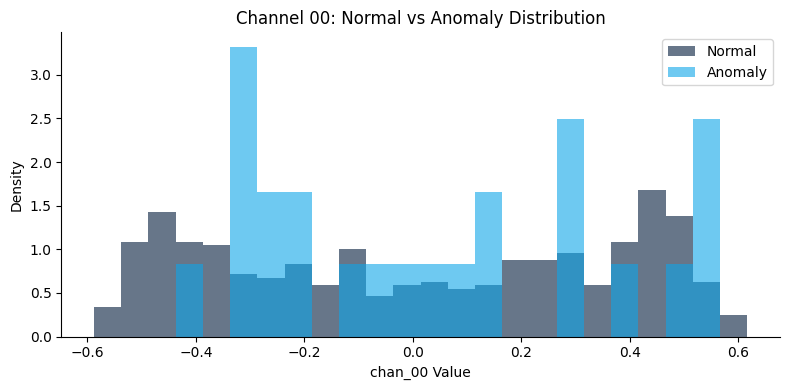

In [22]:
normal  = df[df['anomaly'] == 0]['chan_00']
anomaly = df[df['anomaly'] == 1]['chan_00']

fig, ax = plt.subplots(figsize=(8, 4))

# same bins for both so they can be compared. density=True because there are way fewer anomalies
bins = np.linspace(df['chan_00'].min(), df['chan_00'].max(), 25)
ax.hist(normal,  bins=bins, alpha=0.6, color=NAVY, density=True, label='Normal')
ax.hist(anomaly, bins=bins, alpha=0.6, color=BLUE, density=True, label='Anomaly')

ax.set_xlabel('chan_00 Value')
ax.set_ylabel('Density')
ax.set_title('Channel 00: Normal vs Anomaly Distribution')
ax.legend()
plt.tight_layout()
plt.show()

**Your observation:**

The two histograms look pretty similar and overlap a lot, so `chan_00` by itself does not separate normal from anomaly. This makes sense because the anomalies are spikes in other channels, not in `chan_00`. There are also only a few anomaly points, so the anomaly histogram looks bumpy. (I used density so both groups fit on the same scale.)

## 7 · Reflection

1. What surprised me most is how rare the anomalies are (only about 5% of timesteps) and that each one looks like a sudden spike in just one channel while the other channels look normal. It was also a different channel each time.
2. Since the spikes show up in different channels, a model has to look at all 25 channels together instead of just one. An autoencoder could learn what normal data looks like and then give a high reconstruction error when it sees a spike. Because anomalies are so rare, I think choosing the error threshold will be the hard part.